# 05 — Step 2: Background-Removed Training

**Project:** Tomato Quality Semantic Segmentation — Background Bias Analysis
**Models:** U-Net with MobileNetV2 & EfficientNet-B0 Encoders

## What this notebook does

1. Loads the fixed splits and class weights from notebooks 01 & 02
2. Loads Step 1 results for end-of-notebook comparison
3. Visualises background removal on sample images
4. Trains U-Net/MobileNetV2 on background-removed images (neutral gray 128,128,128)
5. Trains U-Net/EfficientNet-B0 on background-removed images
6. Evaluates both models on the held-out test set (one time only)
7. Plots training curves, confusion matrices, per-class IoU
8. Computes calibration metrics (ECE, reliability diagrams)
9. Visualises predictions and Grad-CAM explainability maps
10. **Step 1 vs Step 2 comparison** — metrics table, 2×2 calibration grid, grouped IoU bar chart
11. Saves `step2_results.pkl` for the grand comparison in notebook 07

> **Research question:** When background pixels are replaced with neutral gray,
> does removing the background cue hurt or help segmentation quality and calibration?

## 1. Imports

In [3]:
import sys
import json
import time
import copy
import random
import pickle
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi']    = 100

print('Imports OK')

Imports OK


## 2. Load Shared Config

In [4]:
sys.path.insert(0, str(Path('..').resolve()))
from config import *

print(f'Device     : {DEVICE}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')

Device     : cpu
OUTPUT_DIR : C:\Personal Data\Thesis\tomato-background-bias\outputs


## 3. Load Splits, Class Weights & Step 1 Results

In [5]:
# ── Splits ───────────────────────────────────────────────────────────────────
assert SPLIT_FILE.exists(), f'Run notebook 01 first: {SPLIT_FILE}'
with open(SPLIT_FILE) as f:
    split_data = json.load(f)

train_pairs = [(INPUT_DIR / img, INPUT_DIR / ann) for img, ann in split_data['train']]
val_pairs   = [(INPUT_DIR / img, INPUT_DIR / ann) for img, ann in split_data['val']]
test_pairs  = [(INPUT_DIR / img, INPUT_DIR / ann) for img, ann in split_data['test']]

print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

# ── Class weights ────────────────────────────────────────────────────────────
WEIGHTS_FILE = OUTPUT_DIR / 'class_weights.npy'
assert WEIGHTS_FILE.exists(), f'Run notebook 02 first: {WEIGHTS_FILE}'
class_weights        = np.load(WEIGHTS_FILE)
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f'Class weights: {class_weights_tensor}')

# ── Step 1 results (for end-of-notebook comparison) ──────────────────────────
STEP1_FILE = OUTPUT_DIR / 'step1_results.pkl'
assert STEP1_FILE.exists(), f'Run notebook 04 first: {STEP1_FILE}'
with open(STEP1_FILE, 'rb') as f:
    step1_results = pickle.load(f)

metrics_m_natural = step1_results['mobilenet']['metrics']
metrics_e_natural = step1_results['efficientnet']['metrics']
cal_m_natural     = step1_results['mobilenet']['calibration']
cal_e_natural     = step1_results['efficientnet']['calibration']
print('Step 1 results loaded for comparison.')

Train: 447 | Val: 93 | Test: 103
Class weights: tensor([0.0227, 1.5775, 1.2734, 0.6377, 1.1389, 1.8030, 0.5468])
Step 1 results loaded for comparison.


## 4. Data Pipeline Functions

In [6]:
# Self-contained copy — identical to notebook 02.
# Any changes must be mirrored there.

def generate_mask_from_annotation(ann_path, img_height=None, img_width=None):
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    h = img_height or ann['size']['height']
    w = img_width  or ann['size']['width']
    mask = np.zeros((h, w), dtype=np.uint8)
    objects_by_class = defaultdict(list)
    for obj in ann['objects']:
        ct = obj.get('classTitle', '')
        if ct in CLASS_TITLE_TO_IDX:
            objects_by_class[ct].append(obj)
    for cls_title in PAINT_PRIORITY:
        if cls_title not in objects_by_class:
            continue
        cls_idx = CLASS_TITLE_TO_IDX[cls_title]
        for obj in objects_by_class[cls_title]:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(mask, [pts], cls_idx)
    return mask


def get_foreground_binary_mask(ann_path, img_height=None, img_width=None):
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    h = img_height or ann['size']['height']
    w = img_width  or ann['size']['width']
    fg = np.zeros((h, w), dtype=np.uint8)
    for obj in ann['objects']:
        if obj.get('classTitle', '') in CLASS_TITLE_TO_IDX:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(fg, [pts], 1)
    return fg


def get_train_augmentation(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.3),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def get_val_augmentation(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


get_test_augmentation = get_val_augmentation


class TomatoSegDataset(Dataset):
    def __init__(self, pairs, transform=None, bg_mode='natural', bg_images=None):
        self.pairs     = pairs
        self.transform = transform
        self.bg_mode   = bg_mode
        self.bg_images = bg_images or []
        missing = [(str(i), str(a)) for i, a in pairs if not i.exists() or not a.exists()]
        if missing:
            raise FileNotFoundError(f'{len(missing)} missing files. First: {missing[0]}')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, ann_p = self.pairs[idx]
        img = cv2.imread(str(img_p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        mask = generate_mask_from_annotation(ann_p, h, w)
        if self.bg_mode == 'removed':
            fg  = get_foreground_binary_mask(ann_p, h, w)
            bg  = np.full_like(img, NEUTRAL_BG_COLOR, dtype=np.uint8)
            fg3 = np.stack([fg] * 3, axis=-1)
            img = np.where(fg3 == 1, img, bg)
        elif self.bg_mode == 'synthetic' and len(self.bg_images) > 0:
            fg     = get_foreground_binary_mask(ann_p, h, w)
            bg_img = cv2.imread(random.choice(self.bg_images))
            if bg_img is not None:
                bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)
                bg_img = cv2.resize(bg_img, (w, h))
            else:
                bg_img = np.random.randint(0, 255, img.shape, dtype=np.uint8)
            fg3 = np.stack([fg] * 3, axis=-1)
            img = np.where(fg3 == 1, img, bg_img)
        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out['image']
            mask = out['mask']
        return img, mask.long()


def make_loaders(train_pairs, val_pairs, test_pairs, bg_mode, bg_images=None):
    train_ds = TomatoSegDataset(train_pairs, transform=get_train_augmentation(),
                                bg_mode=bg_mode, bg_images=bg_images)
    val_ds   = TomatoSegDataset(val_pairs,   transform=get_val_augmentation(),
                                bg_mode=bg_mode, bg_images=bg_images)
    test_ds  = TomatoSegDataset(test_pairs,  transform=get_test_augmentation(),
                                bg_mode=bg_mode, bg_images=bg_images)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE_VAL,   shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE_TEST,  shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


print('Data pipeline functions defined.')

Data pipeline functions defined.


## 5. Model, Loss & Metric Utilities

In [7]:
# Self-contained copy — identical to notebook 03.

def create_unet_model(encoder_name, num_classes=NUM_CLASSES, pretrained='imagenet'):
    return smp.Unet(encoder_name=encoder_name, encoder_weights=pretrained,
                    in_channels=3, classes=num_classes, activation=None).to(DEVICE)


class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None, dice_weight=0.5, ce_weight=0.5,
                 num_classes=NUM_CLASSES, smooth=1e-6):
        super().__init__()
        self.dice_weight = dice_weight
        self.ce_weight   = ce_weight
        self.num_classes = num_classes
        self.smooth      = smooth
        self.ce_loss     = nn.CrossEntropyLoss(weight=class_weights) \
            if class_weights is not None else nn.CrossEntropyLoss()

    def dice_loss(self, pred, target):
        pred_soft      = F.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, self.num_classes).permute(0, 3, 1, 2).float()
        intersection   = (pred_soft * target_one_hot).sum(dim=(2, 3))
        cardinality    = pred_soft.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
        return 1.0 - ((2.0 * intersection + self.smooth) / (cardinality + self.smooth)).mean()

    def forward(self, pred, target):
        return (self.ce_weight * self.ce_loss(pred, target) +
                self.dice_weight * self.dice_loss(pred, target))


def compute_metrics(pred_masks, gt_masks, num_classes=NUM_CLASSES):
    if not pred_masks or not gt_masks:
        return {'pixel_accuracy': 0., 'mean_iou': 0., 'mean_dice': 0.,
                'iou_per_class': np.zeros(num_classes), 'dice_per_class': np.zeros(num_classes),
                'acc_per_class': np.zeros(num_classes),
                'confusion_matrix': np.zeros((num_classes, num_classes)),
                'class_present': np.zeros(num_classes, dtype=bool)}
    all_pred  = np.concatenate([m.flatten() for m in pred_masks])
    all_gt    = np.concatenate([m.flatten() for m in gt_masks])
    pixel_acc = (all_pred == all_gt).mean()
    iou_pc = np.zeros(num_classes); dice_pc = np.zeros(num_classes)
    acc_pc = np.zeros(num_classes); present = np.zeros(num_classes, dtype=bool)
    for c in range(num_classes):
        pc = (all_pred == c); gc = (all_gt == c)
        ps = pc.sum();        gs = gc.sum()
        if gs == 0 and ps == 0:
            iou_pc[c] = dice_pc[c] = acc_pc[c] = float('nan'); continue
        present[c] = True
        inter = (pc & gc).sum(); union = (pc | gc).sum()
        iou_pc[c]  = inter / union         if union > 0   else 0.
        dice_pc[c] = 2 * inter / (ps + gs) if ps + gs > 0 else 0.
        acc_pc[c]  = inter / gs            if gs > 0      else 0.
    mean_iou  = np.nanmean(iou_pc [present]) if present.any() else 0.
    mean_dice = np.nanmean(dice_pc[present]) if present.any() else 0.
    cm = sk_confusion_matrix(all_gt, all_pred, labels=list(range(num_classes)))
    return {'pixel_accuracy': pixel_acc, 'mean_iou': mean_iou, 'mean_dice': mean_dice,
            'iou_per_class': iou_pc, 'dice_per_class': dice_pc, 'acc_per_class': acc_pc,
            'confusion_matrix': cm, 'class_present': present}


def print_metrics(metrics, title='Evaluation Results'):
    print(f"\n{'='*62}\n  {title}\n{'='*62}")
    print(f"  Pixel Accuracy : {metrics['pixel_accuracy']:.4f}")
    print(f"  Mean IoU       : {metrics['mean_iou']:.4f}")
    print(f"  Mean Dice      : {metrics['mean_dice']:.4f}")
    print(f"\n  {'Class':<20} {'IoU':>8} {'Dice':>8} {'Acc':>8}")
    print(f"  {'-'*46}")
    for c in range(NUM_CLASSES):
        i = metrics['iou_per_class'][c]
        d = metrics['dice_per_class'][c]
        a = metrics['acc_per_class'][c]
        i_str = 'N/A' if np.isnan(i) else f'{i:.4f}'
        d_str = 'N/A' if np.isnan(d) else f'{d:.4f}'
        a_str = 'N/A' if np.isnan(a) else f'{a:.4f}'
        print(f"  {CLASS_NAMES[c]:<20} {i_str:>8} {d_str:>8} {a_str:>8}")
    print(f"{'='*62}")


def compute_calibration(pred_probs_list, gt_masks_list, num_bins=15):
    all_conf = []; all_correct = []
    for probs, gt in zip(pred_probs_list, gt_masks_list):
        all_conf.append(probs.max(axis=-1).flatten())
        all_correct.append((probs.argmax(axis=-1) == gt).astype(np.float32).flatten())
    all_conf    = np.concatenate(all_conf)
    all_correct = np.concatenate(all_correct)
    bins = np.linspace(0, 1, num_bins + 1)
    bc = np.zeros(num_bins); ba = np.zeros(num_bins); bct = np.zeros(num_bins)
    for i in range(num_bins):
        m = (all_conf > bins[i]) & (all_conf <= bins[i + 1])
        if m.sum() > 0:
            bc[i] = all_conf[m].mean(); ba[i] = all_correct[m].mean(); bct[i] = m.sum()
    ece = np.sum(bct / bct.sum() * np.abs(ba - bc))
    return {'ece': ece, 'bin_confidences': bc, 'bin_accuracies': ba,
            'bin_counts': bct, 'bin_boundaries': bins}


def plot_reliability_diagram(cal_data, title='Reliability Diagram', ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(7, 7))
    m = cal_data['bin_counts'] > 0
    ax.bar(cal_data['bin_confidences'][m], cal_data['bin_accuracies'][m],
           width=1. / len(cal_data['bin_counts']), alpha=0.6,
           color='steelblue', edgecolor='navy', label='Actual accuracy')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration')
    ax.set_xlabel('Confidence', fontsize=12); ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'{title}\nECE = {cal_data["ece"]:.4f}', fontsize=13)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=11); ax.set_aspect('equal')
    return ax


print('Model, loss, metric utilities defined.')

Model, loss, metric utilities defined.


In [8]:
# ── Training loops with tqdm (identical pattern to notebook 04) ──────────────

def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    rl   = 0.
    pbar = tqdm(loader, desc='  Train', leave=False, unit='batch')
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()
        rl += loss.item() * imgs.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    return rl / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE, return_predictions=False):
    model.eval()
    rl = 0.; pm = []; gm = []; pp = []
    pbar = tqdm(loader, desc='  Eval ', leave=False, unit='batch')
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        out  = model(imgs)
        rl  += criterion(out, masks).item() * imgs.size(0)
        probs = F.softmax(out, dim=1)
        preds = probs.argmax(dim=1)
        for b in range(preds.shape[0]):
            pm.append(preds[b].cpu().numpy())
            gm.append(masks[b].cpu().numpy())
            if return_predictions:
                pp.append(probs[b].cpu().numpy().transpose(1, 2, 0))
    avg_loss = rl / len(loader.dataset)
    metrics  = compute_metrics(pm, gm)
    if return_predictions:
        return avg_loss, metrics, pm, gm, pp
    return avg_loss, metrics


def train_model(model, train_loader, val_loader, test_loader, criterion,
                optimizer, scheduler, num_epochs=NUM_EPOCHS,
                patience=EARLY_STOP_PATIENCE, model_name='model', device=DEVICE):
    best_miou  = 0.; best_epoch = 0; best_state = None; no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'test_loss': [],
               'train_miou': [], 'val_miou': [],
               'train_pixel_acc': [], 'val_pixel_acc': []}

    print(f"{'='*60}\n  Training: {model_name}\n{'='*60}")
    epoch_pbar = tqdm(range(1, num_epochs + 1), desc='Epochs', unit='epoch')
    for epoch in epoch_pbar:
        t0 = time.time()
        tl     = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, vm = evaluate(model, val_loader,   criterion, device)
        _,  tm = evaluate(model, train_loader, criterion, device)
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(vl)
            else:
                scheduler.step()
        history['train_loss'].append(tl);      history['val_loss'].append(vl)
        history['train_miou'].append(tm['mean_iou'])
        history['val_miou'].append(vm['mean_iou'])
        history['train_pixel_acc'].append(tm['pixel_accuracy'])
        history['val_pixel_acc'].append(vm['pixel_accuracy'])
        elapsed = time.time() - t0
        if vm['mean_iou'] > best_miou:
            best_miou  = vm['mean_iou']; best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0; marker = '  BEST'
        else:
            no_improve += 1; marker = ''
        epoch_pbar.set_postfix({
            'TrLoss': f'{tl:.4f}', 'VaLoss': f'{vl:.4f}',
            'TrmIoU': f'{tm["mean_iou"]:.4f}', 'VamIoU': f'{vm["mean_iou"]:.4f}',
            'Best'  : f'{best_miou:.4f}',
        })
        tqdm.write(
            f'  Epoch {epoch:3d}/{num_epochs} | '
            f'TrLoss:{tl:.4f}  VaLoss:{vl:.4f} | '
            f'TrmIoU:{tm["mean_iou"]:.4f}  VamIoU:{vm["mean_iou"]:.4f} | '
            f'{elapsed:.1f}s{marker}'
        )
        if no_improve >= patience:
            tqdm.write(f'\n  Early stopping at epoch {epoch}'); break

    if best_state:
        model.load_state_dict(best_state)
    sp = OUTPUT_DIR / f'{model_name}_best.pth'
    torch.save(best_state, sp)
    tqdm.write(f'\n  Best Val mIoU : {best_miou:.4f} at epoch {best_epoch}')
    tqdm.write(f'  Model saved   -> {sp}')
    tqdm.write('  Evaluating TEST SET (first and only time)...')
    test_loss, test_metrics = evaluate(model, test_loader, criterion, device)
    history['test_loss'].append(test_loss)
    tqdm.write(f'  Test mIoU : {test_metrics["mean_iou"]:.4f} | '
               f'PixAcc : {test_metrics["pixel_accuracy"]:.4f}')
    return model, history, test_metrics


print('Training loops defined (tqdm progress bars enabled).')

Training loops defined (tqdm progress bars enabled).


In [9]:
def plot_training_history(history, model_name='Model'):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    for ax, (tk, vk, yl, ttl) in zip(axes, [
        ('train_loss', 'val_loss', 'Loss', 'Loss'),
        ('train_miou', 'val_miou', 'Mean IoU', 'Mean IoU'),
        ('train_pixel_acc', 'val_pixel_acc', 'Pixel Acc', 'Pixel Accuracy'),
    ]):
        ax.plot(epochs, history[tk], 'b-', label='Train')
        ax.plot(epochs, history[vk], 'r-', label='Val')
        ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
        ax.set_title(f'{model_name} — {ttl}'); ax.legend()
    plt.tight_layout()
    safe = model_name.replace(' ', '_').replace('—', '-')
    plt.savefig(OUTPUT_DIR / f'{safe}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def visualize_predictions(model, dataset, indices, model_name='Model',
                          device=DEVICE, num_samples=8):
    model.eval()
    n = min(num_samples, len(indices))
    fig, axes = plt.subplots(n, 3, figsize=(18, 5 * n))
    if n == 1: axes = axes[np.newaxis, :]
    dm = np.array([0.485, 0.456, 0.406]); ds = np.array([0.229, 0.224, 0.225])
    for row, idx in enumerate(indices[:n]):
        it, mt = dataset[idx]
        img_np = (it.numpy().transpose(1, 2, 0) * ds + dm).clip(0, 1)
        with torch.no_grad():
            pm = model(it.unsqueeze(0).to(device)).argmax(dim=1).squeeze(0).cpu().numpy()
        gm = mt.numpy()
        gc = np.zeros((*gm.shape, 3), dtype=np.uint8)
        pc = np.zeros((*pm.shape, 3), dtype=np.uint8)
        for c in range(NUM_CLASSES):
            gc[gm == c] = CLASS_COLORS[c]; pc[pm == c] = CLASS_COLORS[c]
        for col, (im, ttl) in enumerate([
            (img_np, 'Input'), (gc, 'Ground Truth'), (pc, 'Prediction')
        ]):
            axes[row, col].imshow(im); axes[row, col].set_title(ttl); axes[row, col].axis('off')
    patches = [mpatches.Patch(color=np.array(CLASS_COLORS[i]) / 255., label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=10, bbox_to_anchor=(0.5, -0.01))
    plt.suptitle(f'{model_name} — Predictions', fontsize=14, y=1.01)
    plt.tight_layout()
    safe = model_name.replace(' ', '_').replace('—', '-')
    plt.savefig(OUTPUT_DIR / f'{safe}_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(cm, title='Confusion Matrix'):
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=13); plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            v = cm_norm[i, j]
            if v > 0.005:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='white' if v > 0.5 else 'black', fontsize=8)
    plt.tight_layout(); return fig


class SemanticSegmentationTarget:
    def __init__(self, category, mask=None): self.category = category; self.mask = mask
    def __call__(self, model_output):
        if self.mask is not None: return (model_output[self.category] * self.mask).sum()
        return model_output[self.category].sum()


def generate_gradcam_for_image(model, img_tensor, target_class, target_layer, device=DEVICE):
    targets = [SemanticSegmentationTarget(target_class)]
    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        gc = cam(input_tensor=img_tensor.unsqueeze(0).to(device), targets=targets)[0]
    dm = np.array([0.485, 0.456, 0.406]); ds = np.array([0.229, 0.224, 0.225])
    img_np = (img_tensor.numpy().transpose(1, 2, 0) * ds + dm).clip(0, 1).astype(np.float32)
    return show_cam_on_image(img_np, gc, use_rgb=True), gc


def visualize_gradcam_gallery(model, dataset, indices, target_classes,
                              target_layer, model_name='Model', device=DEVICE):
    n_imgs = len(indices); n_cls = len(target_classes)
    fig, axes = plt.subplots(n_imgs, n_cls + 1, figsize=(5 * (n_cls + 1), 5 * n_imgs))
    if n_imgs == 1: axes = axes[np.newaxis, :]
    dm = np.array([0.485, 0.456, 0.406]); ds = np.array([0.229, 0.224, 0.225])
    for row, idx in enumerate(indices):
        it, _ = dataset[idx]
        img_np = (it.numpy().transpose(1, 2, 0) * ds + dm).clip(0, 1)
        axes[row, 0].imshow(img_np); axes[row, 0].set_title('Input', fontsize=10); axes[row, 0].axis('off')
        for col, ci in enumerate(target_classes):
            cam_img, _ = generate_gradcam_for_image(model, it, ci, target_layer, device)
            axes[row, col + 1].imshow(cam_img)
            axes[row, col + 1].set_title(f'GradCAM: {CLASS_NAMES[ci]}', fontsize=10)
            axes[row, col + 1].axis('off')
    plt.suptitle(f'{model_name} — Grad-CAM', fontsize=14, y=1.01); plt.tight_layout()
    safe = model_name.replace(' ', '_').replace('—', '-')
    plt.savefig(OUTPUT_DIR / f'{safe}_gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Visualisation and Grad-CAM utilities defined.')

Visualisation and Grad-CAM utilities defined.


## 6. Visualise Background Removal on Sample Images

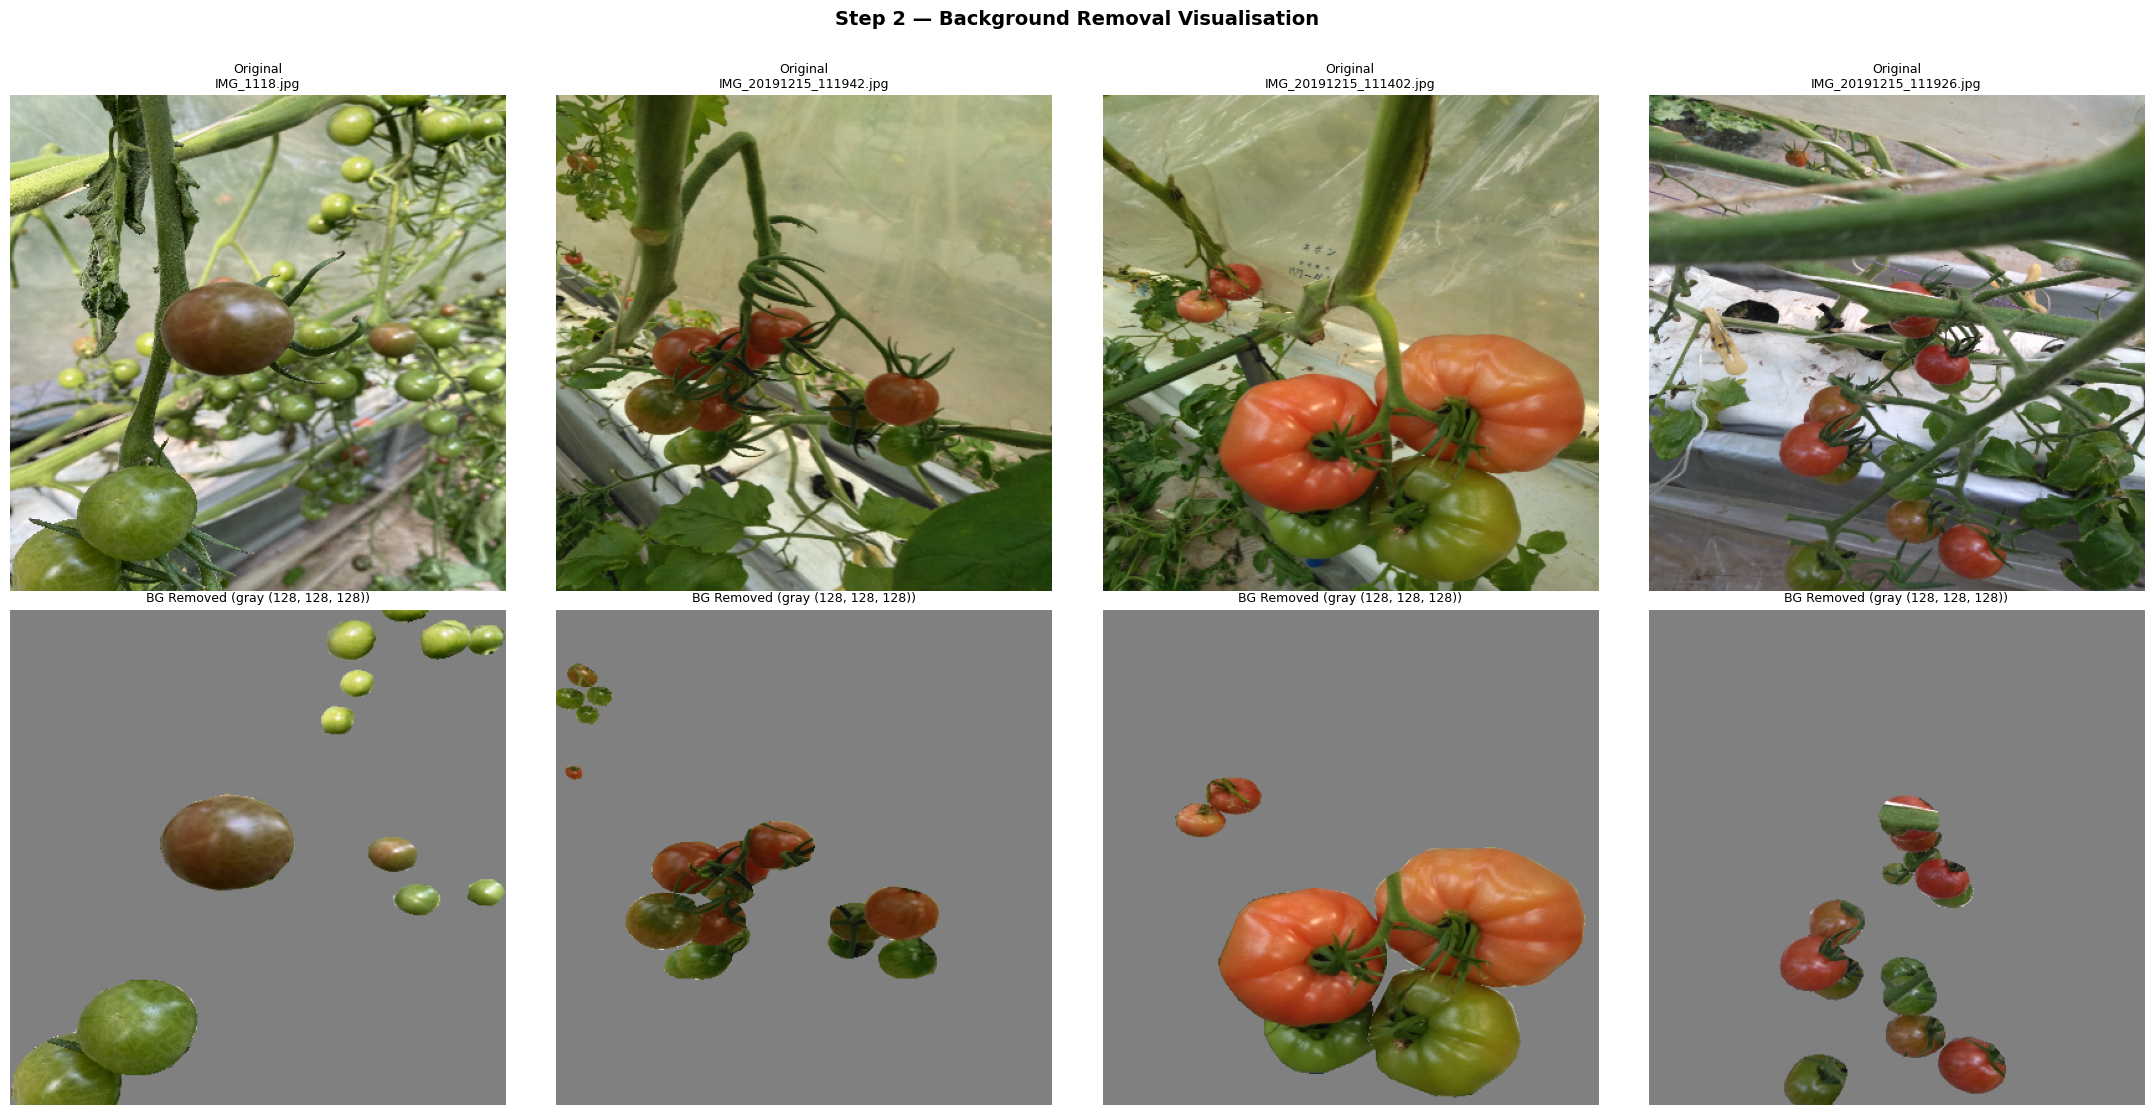

Saved: step2_bg_removal_samples.png


In [10]:
sample_vis = random.sample(train_pairs, 4)
fig, axes  = plt.subplots(2, 4, figsize=(22, 11))

for i, (img_p, ann_p) in enumerate(sample_vis):
    img     = cv2.imread(str(img_p))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]
    fg      = get_foreground_binary_mask(ann_p, h, w)
    bg      = np.full_like(img_rgb, NEUTRAL_BG_COLOR)
    fg3     = np.stack([fg] * 3, axis=-1)
    removed = np.where(fg3 == 1, img_rgb, bg)

    disp = (400, 400)
    axes[0, i].imshow(cv2.resize(img_rgb, disp))
    axes[0, i].set_title(f'Original\n{img_p.name}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(cv2.resize(removed, disp))
    axes[1, i].set_title(f'BG Removed (gray {NEUTRAL_BG_COLOR})', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Step 2 — Background Removal Visualisation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step2_bg_removal_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step2_bg_removal_samples.png')

## 7. Build Background-Removed DataLoaders

In [11]:
print('Building BG-removed loaders...')
(train_loader_removed, val_loader_removed, test_loader_removed,
 train_ds_removed,     val_ds_removed,     test_ds_removed) = make_loaders(
    train_pairs, val_pairs, test_pairs, bg_mode='removed'
)

print(f'Train: {len(train_ds_removed)} | Val: {len(val_ds_removed)} | Test: {len(test_ds_removed)}')
imgs, masks = next(iter(train_loader_removed))
print(f'Batch — imgs: {tuple(imgs.shape)}  masks: {tuple(masks.shape)}  dtype: {masks.dtype}')

Building BG-removed loaders...
Train: 447 | Val: 93 | Test: 103
Batch — imgs: (8, 3, 512, 512)  masks: (8, 512, 512)  dtype: torch.int64


## 8. Train U-Net / MobileNetV2 (BG Removed)

In [12]:
print('Creating U-Net with MobileNetV2 encoder...')
model_mobilenet_removed = create_unet_model('mobilenet_v2')

total     = sum(p.numel() for p in model_mobilenet_removed.parameters())
trainable = sum(p.numel() for p in model_mobilenet_removed.parameters() if p.requires_grad)
print(f'Parameters — Total: {total:,}  Trainable: {trainable:,}')

criterion_m = CombinedLoss(class_weights=class_weights_tensor).to(DEVICE)
optimizer_m = torch.optim.Adam(model_mobilenet_removed.parameters(),
                               lr=LEARNING_RATE, weight_decay=1e-5)
scheduler_m = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_m, T_max=NUM_EPOCHS, eta_min=1e-6)

model_mobilenet_removed, history_m_removed, test_metrics_m_removed = train_model(
    model_mobilenet_removed,
    train_loader_removed, val_loader_removed, test_loader_removed,
    criterion_m, optimizer_m, scheduler_m,
    num_epochs=NUM_EPOCHS, patience=EARLY_STOP_PATIENCE,
    model_name='step2_mobilenetv2_removed'
)

Creating U-Net with MobileNetV2 encoder...
Parameters — Total: 6,629,815  Trainable: 6,629,815
  Training: step2_mobilenetv2_removed


Epochs:   2%|▎         | 1/40 [18:10<11:48:49, 1090.51s/epoch, TrLoss=1.2125, VaLoss=0.9316, TrmIoU=0.2660, VamIoU=0.3033, Best=0.3033]

  Epoch   1/40 | TrLoss:1.2125  VaLoss:0.9316 | TrmIoU:0.2660  VamIoU:0.3033 | 1090.4s  BEST


Epochs:   2%|▎         | 1/40 [25:56<16:51:49, 1556.65s/epoch, TrLoss=1.2125, VaLoss=0.9316, TrmIoU=0.2660, VamIoU=0.3033, Best=0.3033]


KeyboardInterrupt: 

## 9. Train U-Net / EfficientNet-B0 (BG Removed)

In [ ]:
print('Creating U-Net with EfficientNet-B0 encoder...')
model_effnet_removed = create_unet_model('efficientnet-b0')

total     = sum(p.numel() for p in model_effnet_removed.parameters())
trainable = sum(p.numel() for p in model_effnet_removed.parameters() if p.requires_grad)
print(f'Parameters — Total: {total:,}  Trainable: {trainable:,}')

criterion_e = CombinedLoss(class_weights=class_weights_tensor).to(DEVICE)
optimizer_e = torch.optim.Adam(model_effnet_removed.parameters(),
                               lr=LEARNING_RATE, weight_decay=1e-5)
scheduler_e = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_e, T_max=NUM_EPOCHS, eta_min=1e-6)

model_effnet_removed, history_e_removed, test_metrics_e_removed = train_model(
    model_effnet_removed,
    train_loader_removed, val_loader_removed, test_loader_removed,
    criterion_e, optimizer_e, scheduler_e,
    num_epochs=NUM_EPOCHS, patience=EARLY_STOP_PATIENCE,
    model_name='step2_efficientnetb0_removed'
)

## 10. Training Curves

In [ ]:
plot_training_history(history_m_removed, 'Step2 — MobileNetV2 (BG Removed)')
plot_training_history(history_e_removed, 'Step2 — EfficientNet-B0 (BG Removed)')

## 11. Full Test-Set Evaluation

In [ ]:
print('Evaluating MobileNetV2 (BG removed)...')
_, metrics_m_removed, pred_masks_m, gt_masks_m, pred_probs_m = evaluate(
    model_mobilenet_removed, test_loader_removed, criterion_m, return_predictions=True)
print_metrics(metrics_m_removed, 'Step 2 — MobileNetV2 (BG Removed)')

fig = plot_confusion_matrix(metrics_m_removed['confusion_matrix'],
                            'Step 2 — MobileNetV2 (BG Removed)')
plt.savefig(OUTPUT_DIR / 'step2_mobilenetv2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEvaluating EfficientNet-B0 (BG removed)...')
_, metrics_e_removed, pred_masks_e, gt_masks_e, pred_probs_e = evaluate(
    model_effnet_removed, test_loader_removed, criterion_e, return_predictions=True)
print_metrics(metrics_e_removed, 'Step 2 — EfficientNet-B0 (BG Removed)')

fig = plot_confusion_matrix(metrics_e_removed['confusion_matrix'],
                            'Step 2 — EfficientNet-B0 (BG Removed)')
plt.savefig(OUTPUT_DIR / 'step2_efficientnetb0_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Calibration Analysis — Step 2

In [ ]:
cal_m_removed = compute_calibration(pred_probs_m, gt_masks_m)
cal_e_removed = compute_calibration(pred_probs_e, gt_masks_e)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plot_reliability_diagram(cal_m_removed, 'MobileNetV2 (BG Removed)',     ax=axes[0])
plot_reliability_diagram(cal_e_removed, 'EfficientNet-B0 (BG Removed)', ax=axes[1])
plt.suptitle('Step 2 — Calibration: Reliability Diagrams', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step2_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ECE — MobileNetV2    : {cal_m_removed["ece"]:.4f}')
print(f'ECE — EfficientNet-B0: {cal_e_removed["ece"]:.4f}')

## 13. Prediction Visualisations

In [ ]:
test_indices = list(range(0, min(len(test_ds_removed), 80), 10))[:8]

visualize_predictions(model_mobilenet_removed, test_ds_removed, test_indices,
                      model_name='Step2 — MobileNetV2 (BG Removed)')
visualize_predictions(model_effnet_removed, test_ds_removed, test_indices,
                      model_name='Step2 — EfficientNet-B0 (BG Removed)')

## 14. Grad-CAM Explainability

In [ ]:
gradcam_classes = [0, 1, 2, 3, 4, 5, 6] 
gradcam_indices = list(range(0, min(len(test_ds_removed), 50), 10))[:5]

target_layer_m = model_mobilenet_removed.segmentation_head[0]
target_layer_e = model_effnet_removed.segmentation_head[0]

print('Generating Grad-CAM for MobileNetV2 (BG Removed)...')
visualize_gradcam_gallery(
    model_mobilenet_removed, test_ds_removed, gradcam_indices,
    gradcam_classes, target_layer_m, model_name='Step2 — MobileNetV2 (BG Removed)')

print('\nGenerating Grad-CAM for EfficientNet-B0 (BG Removed)...')
visualize_gradcam_gallery(
    model_effnet_removed, test_ds_removed, gradcam_indices,
    gradcam_classes, target_layer_e, model_name='Step2 — EfficientNet-B0 (BG Removed)')

## 15. Step 1 vs Step 2 — Full Comparison

Three panels:
- **Metrics table** — pixel acc, mIoU, Dice, ECE side by side
- **2×2 reliability diagram grid** — Natural BG vs BG Removed for each encoder
- **Grouped per-class IoU bar chart** — Natural BG vs BG Removed bars per class

In [ ]:
# ── Metrics comparison table ──────────────────────────────────────────────────
rows = []
for enc, m_nat, m_rem, cal_nat, cal_rem in [
    ('MobileNetV2',     metrics_m_natural, metrics_m_removed, cal_m_natural, cal_m_removed),
    ('EfficientNet-B0', metrics_e_natural, metrics_e_removed, cal_e_natural, cal_e_removed),
]:
    for step, m, cal in [
        ('Step 1 — Natural',  m_nat, cal_nat),
        ('Step 2 — Removed',  m_rem, cal_rem),
    ]:
        rows.append({
            'Encoder'   : enc,
            'Condition' : step,
            'Pixel Acc' : f"{m['pixel_accuracy']:.4f}",
            'Mean IoU'  : f"{m['mean_iou']:.4f}",
            'Mean Dice' : f"{m['mean_dice']:.4f}",
            'ECE'       : f"{cal['ece']:.4f}",
        })

comp_df = pd.DataFrame(rows)
print('\n=== Step 1 vs Step 2 — Metrics Comparison ===')
print(comp_df.to_string(index=False))

In [ ]:
# ── 2×2 Calibration comparison grid ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

plot_reliability_diagram(cal_m_natural, 'MobileNetV2 — Natural BG',     ax=axes[0, 0])
plot_reliability_diagram(cal_m_removed, 'MobileNetV2 — BG Removed',     ax=axes[0, 1])
plot_reliability_diagram(cal_e_natural, 'EfficientNet-B0 — Natural BG', ax=axes[1, 0])
plot_reliability_diagram(cal_e_removed, 'EfficientNet-B0 — BG Removed', ax=axes[1, 1])

plt.suptitle('Step 1 vs Step 2 — Calibration Comparison (Reliability Diagrams)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step1_vs_step2_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nECE delta (Removed − Natural):')
for enc, cal_nat, cal_rem in [
    ('MobileNetV2',     cal_m_natural, cal_m_removed),
    ('EfficientNet-B0', cal_e_natural, cal_e_removed),
]:
    delta = cal_rem['ece'] - cal_nat['ece']
    direction = 'better calibrated' if delta < 0 else 'worse calibrated'
    print(f'  {enc:<18}  Natural:{cal_nat["ece"]:.4f}  Removed:{cal_rem["ece"]:.4f}  '
          f'delta:{delta:+.4f}  ({direction})')
print('Saved: step1_vs_step2_calibration.png')

In [ ]:
# ── Grouped per-class IoU bar chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
x     = np.arange(NUM_CLASSES)
width = 0.35

for ax, m_nat, m_rem, label in [
    (axes[0], metrics_m_natural, metrics_m_removed, 'MobileNetV2'),
    (axes[1], metrics_e_natural, metrics_e_removed, 'EfficientNet-B0'),
]:
    nat_iou = np.nan_to_num(m_nat['iou_per_class'], nan=0.)
    rem_iou = np.nan_to_num(m_rem['iou_per_class'], nan=0.)
    bars_nat = ax.bar(x - width / 2, nat_iou, width, label='Step 1: Natural BG',
                      color='#2196F3', alpha=0.85, edgecolor='white')
    bars_rem = ax.bar(x + width / 2, rem_iou, width, label='Step 2: BG Removed',
                      color='#FF5722', alpha=0.85, edgecolor='white')
    for bar, v in list(zip(bars_nat, nat_iou)) + list(zip(bars_rem, rem_iou)):
        if v > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=0)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('IoU', fontsize=10); ax.set_ylim(0, 1.15)
    ax.set_title(f'{label} — Per-Class IoU\nStep 1 (Natural) vs Step 2 (Removed)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('Step 1 vs Step 2 — Per-Class IoU Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step1_vs_step2_iou_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step1_vs_step2_iou_comparison.png')

## 16. Save Results for Grand Comparison

In [ ]:
step2_results = {
    'mobilenet'   : {'metrics': metrics_m_removed, 'calibration': cal_m_removed,
                     'history': history_m_removed},
    'efficientnet': {'metrics': metrics_e_removed, 'calibration': cal_e_removed,
                     'history': history_e_removed},
}

with open(OUTPUT_DIR / 'step2_results.pkl', 'wb') as f:
    pickle.dump(step2_results, f)

print('Results saved -> outputs/step2_results.pkl')

## 17. Summary

In [ ]:
print('=' * 65)
print('  NOTEBOOK 05 — STEP 2 COMPLETE')
print('=' * 65)
print('  Background condition : Removed (neutral gray 128, 128, 128)')
print()
print(f'  {"Model":<22} {"Condition":<18} {"Pixel Acc":>10} {"Mean IoU":>10} {"ECE":>8}')
print(f'  {"-"*70}')
for enc, m_nat, m_rem, cal_nat, cal_rem in [
    ('MobileNetV2',     metrics_m_natural, metrics_m_removed, cal_m_natural, cal_m_removed),
    ('EfficientNet-B0', metrics_e_natural, metrics_e_removed, cal_e_natural, cal_e_removed),
]:
    print(f'  {enc:<22} {"Natural BG":<18} '
          f'{m_nat["pixel_accuracy"]:>10.4f} {m_nat["mean_iou"]:>10.4f} {cal_nat["ece"]:>8.4f}')
    delta = m_rem["mean_iou"] - m_nat["mean_iou"]
    print(f'  {"" :<22} {"BG Removed":<18} '
          f'{m_rem["pixel_accuracy"]:>10.4f} {m_rem["mean_iou"]:>10.4f} {cal_rem["ece"]:>8.4f} '
          f'  (IoU delta: {delta:+.4f})')
    print()
print('  Saved files:')
for fp in sorted(OUTPUT_DIR.glob('step2_*')):
    print(f'    {fp.name}')
for fp in sorted(OUTPUT_DIR.glob('step1_vs_step2_*')):
    print(f'    {fp.name}')
print()
print('  Next: run 06_step3_synthetic_backgrounds.ipynb')
print('=' * 65)

In [ ]:
!jupyter nbconvert --to html 05_step2_background_removed.ipynb 

[NbConvertApp] Converting notebook 05_step2_background_removed.ipynb to html
[NbConvertApp] Writing 494095 bytes to 05_step2_background_removed.html
